# Background

To build a radar map of the moon, we want to process all of the available data (many "Looks" across many days) into intensity values for each point on the moon's surface.

In essence, we combine samples over a duration of a few minutes into a coherent doppler/delay (DD) Look, which we then map to intensity values the moon's surface. We can repeat this process for each Look, and then incoherently combine the Looks by taking the average of the intensity values at each point, for instance.

There are several relevant frames:
* The RX frame (at Stockert)
* The TX frame (at Dwingeloo)
* The Moon frame, which is where the bounces occur.
 - The Moon is significantly not spherical, which requires raycasting to model accurately!

Bouncing a radar signal from the transmitter to the moon to the receiver causes a Doppler effect, which is usually though of as a change in frequency or pitch. This effect can be interpreted in the frequency domain, or the time domain:
* Frequency Domain: at each tx or rx sample time, there is an instantaneous frequency shift caused by the relative velocity of the two bodies during the signal round trip -- this is the classical Doppler shift.
* Time Domain: at each rx sample time, there is a corrected tx sample timing caused by the signal propagation delay. The effect of shifting the signal timing is to cause an apparent frequency shift!

Both of these effects cause a frequency shift, but the time domain interpretation is more accurate, since it also corrects for the timing of various signal events (start, stop, internal structure). We will use the term Doppler shift or Doppler effect to generically refer the overall phenomenon, which can be modeled using either of these interpretations.

(AM I RIGHT ABOUT THIS OR COMPLETELY BONKERS?)

(IN IMPLEMENTATION, IS TIME DOMAIN INTERPOLATION ACTUALLY BETTER, COMPARED WITH FREQUENCY DOMAIN SHIFTING?)

(DO WE HAVE A HIGH-PRECISION DESCRIPTION OF THE TX SIGNAL THAT WE COULD SUPER-SAMPLE?)

Because of light time delays, and the changing relative motion of the Earth and Moon, and oblateness of the Moon, we need to use relativistic raycasting to model the Doppler and delay .

The most tricky part is assembling the Looks. We have several options to convert the samples into moon surface values.
1. Full relativistic raycast: for each rx sample of the Look, cast a BACK ray to each point on the moon and then a BACK ray to the TX. Correct the TX sample timing accordingly and correlate the corrected signal over the duration of the Look with the RX signal to get the moon surface intensity at that point. This takes into account the full complexity of the light propagation and relative motion of the 3 points of interest (tx, bounce, rx).
    1. NOTE: this is likely very computationally intensive!
2. Sub-radar point SRP) relativistic raycast. The change in relative motion (and thus doppler) due to the delay depth of the moon is probably pretty small. So we can instead just use the SRP (rather than each point on the moon) to estimate the Doppler correction.
    1. Then correct the {RX or TX TBD} samples:
        1. Time domain: Resample the TX or RX signal to the adjusted timestamps
        2. Frequency domain: Shift the {RX, TX} signal frequency by the time-varying doppler
    2. Correlate the corrected signal with the (original) {OTHER} signal across a range of doppler shifts (due to the motion of the limbs of the moon): this yields a single "look" at the rx signal start time
    3. Then raycast for points on the lunar surface to predict the dopplers/delays of at the "look" time for each point, and convert the "look" doppler/delay intensity values into moon coordinates.
3. Sub-radar, linear rate of Doppler. Like 2, but instead of computing the corrected sample timing or instantaneous frequency shift for each sample, just compute them for the {RX, TX} start and end times and assume a linear rate in between. Use this simpler correction for (2.A), then do (2.B) and (2.C) as in (2).
    1. NOTE: this is what we've been doing (frequency domain only)

Residual issues:
* I suspect, due to my lack of understanding of what it means for two separate locations (Dwingeloo and Stockert) to both use UTC and claim simultaneous events in those two locations, that there may be a residual time offset correction between the two sites. Due to the geometry of the sitation, this time offset is probably near-constant during a Look, but may vary between looks.
* We've been seeing hints of this the whole time, in odd offsets in delay or cross-correlation peaks.
* We may be able to identify the time offset correction by searching for the offset that maximizes the tx-to-rx correlation.


## Basic principle of Planetary Radar:
Transmit short pulses at a given frequency for distance/c time
 * pulse duration should be ... pretty short (have to sum up many pulses to deal with noise)
 * pulse interval should be longer than the delay dispersion
 * or use coded long pulse waveform (pseudo-random)
 * Receive the echos, compute the response for each cell in a doppler delay grid (doppler varies across the limbs, delay varies with distance)

## Relevant papers
 * [Radar Echoes From the Moon](https://web.archive.org/web/20081029000712/http://www.eagle.ca/~harry/ba/eme/index.htm) -- historical
 * [Planetary Radar - State-of-the-Art Review](https://www.mdpi.com/2072-4292/15/23/5605) -- 2023 overview
 * [Planetary Radar Astronomy](https://nap.nationalacademies.org/read/21729/chapter/8) -- 2015 overview
 * [Planetary Radar](https://echo.jpl.nasa.gov/asteroids/ostro_1998_encyc_ss.pdf) -- 1998 overview
 * [Planetary Delay-Doppler Radar and the Long-Code Method](https://echo.jpl.nasa.gov/asteroids/harmon.2002.long.code.pdf) -- long-code method (recommends intercode -- coherent code sequence) for underspread Moon
 * [Earth-Based Radar Observations of Venus -- PDS Archive Description](https://pds-geosciences.wustl.edu/venus/arcb_nrao-v-rtls_gbt-3-delaydoppler-v1/vrm_90xx/document/venus_radar.pdf) -- Arecibo Venus data description

In [1]:
# To fetch the camras data, use something like:
#! wget -r --no-clobber --no-parent -R index.html?* https://data.camras.nl/thomas/sdr-eme/

In [2]:
# Install dependencies
#! pip install --quiet --upgrade astropy astroquery cspyce cupy-cuda12x healpy ipympl jplephem matplotlib numpy scipy sigmf tqdm

# Imports and configuration

In [3]:
import os
import pickle

import numpy as np
from matplotlib import pyplot as pl

from astropy import units as au
from astropy import constants as ak
from astropy import coordinates as ac
from astropy import time as at

import healpy as hp

import cspyce as csp

import cupy

import scipy
import sigmf
from tqdm import tqdm

In [4]:
#TX_START = 1.0 * au.s          # Time after rx file start that transmission started
TX_START = 1.000028 * au.s       # HACK HACK HACK -- Produces best peak correlation!?   # Time after rx file start that transmission started
MOON_RADIUS = 1_737_400.0 * au.m   # Volumetric mean radius

# File handling

In [5]:
DATA_ROOT = 'data'

# Load the rx data
def loadRxTxFiles(rx_chan0_sigmf_filename):
    # For Dwingeloo (not sure about Stockert):
    # - Chan 0 is RHCP
    # - Chan 1 is LHCP
    
    if 1: # Just use one polarity 
        print(f"Loading RX file {rx_chan0_sigmf_filename}")
        rx_chan0_sigmf_file = sigmf.sigmffile.fromfile(rx_chan0_sigmf_filename)
        rx_samples = rx_chan0_sigmf_file.read_samples().astype("complex64")

    if 0: # Combine both polarities:
        print(f"Loading RX files ")
        print(f"  Loading RX file {rx_chan0_sigmf_filename}")
        rx_chan0_sigmf_file = sigmf.sigmffile.fromfile(rx_chan0_sigmf_filename)
        rx_chan0_samples = rx_chan0_sigmf_file.read_samples().astype("complex64")
        
        rx_chan1_sigmf_filename = rx_chan0_sigmf_filename.replace("chan0", "chan1")
        print(f"  Loading RX file {rx_chan1_sigmf_filename}")
        rx_chan1_sigmf_file = sigmf.sigmffile.fromfile(rx_chan1_sigmf_filename)
        rx_chan1_samples = rx_chan1_sigmf_file.read_samples().astype("complex64")
    
        ## Normalize by the average channel power.
        rx_chan0_samples /= np.mean(np.abs(rx_chan0_samples))
        rx_chan1_samples /= np.mean(np.abs(rx_chan1_samples))
        
        # From Thomas' code: Combine RHCP at 80 degrees (cross-pol), LHCP at 260 (co-pol)
        rx_samples = rx_chan0_samples + np.exp(1j * 260 * np.pi / 180) * rx_chan1_samples
    
    rx_info = rx_chan0_sigmf_file.get_global_info()
    #display(rx_info) 
    sample_rate = rx_info['core:sample_rate'] / au.s
    tx_filename = rx_info['core:description']
    rx_captures = rx_chan0_sigmf_file.get_captures()
    #display(rx_captures[0])
    frequency = rx_captures[0]['core:frequency'] * au.Hz
    rx_start_astrotime = at.Time(rx_captures[0]['core:datetime'])

    if "2025-06-21" in rx_chan0_sigmf_filename:
        tx_sigmf_filename = f"{DATA_ROOT}/sdr-eme/tx-2025-06-21/{tx_filename}"
    else:
        tx_sigmf_filename = f"{DATA_ROOT}/sdr-eme/tx/{tx_filename}"
    print(f"  Loading TX file {tx_sigmf_filename}")
    tx_sigmf_file = sigmf.sigmffile.fromfile(tx_sigmf_filename)
    tx_info = tx_sigmf_file.get_global_info()
    #display(tx_info)
    tx_samples = tx_sigmf_file.read_samples().astype("complex64")
    tx_captures = tx_sigmf_file.get_captures()
    #display(tx_captures[0])

    assert rx_info['core:sample_rate'] == tx_info['core:sample_rate'], "RX and TX sample rate expected to be the same"
    assert rx_captures[0]['core:frequency'] == tx_captures[0]['core:frequency'], "RX and TX frequency expected to be the same"
    
    return rx_samples, tx_samples, sample_rate, frequency, rx_start_astrotime

if 1:
    rx_chan0_sigmf_filename = f"{DATA_ROOT}/sdr-eme/rx-2025-03-11/stockert_eme_2025_03_11_19_36_21_1297.500MHz_1.00Msps_ci16_le.chan0.sigmf-meta"  # 60s tx, 66s rx!
    #rx_chan0_sigmf_filename = f"{DATA_ROOT}/sdr-eme/rx-2025-06-21/stockert_eme_2025_06_21_10_06_39_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta"  # 60s tx, 66s rx!
    rx_samples, tx_samples, sample_rate, frequency, rx_start_astrotime = loadRxTxFiles(rx_chan0_sigmf_filename)

Loading RX file data/sdr-eme/rx-2025-03-11/stockert_eme_2025_03_11_19_36_21_1297.500MHz_1.00Msps_ci16_le.chan0.sigmf-meta
  Loading TX file data/sdr-eme/tx/zadoff-chu-50000-1500007-503-0-30-1.sigmf-meta


In [6]:
# Download SPICE kernels for cspyce
# Inspired from Thomas' notebook, in turn from https://github.com/daniestevez/jupyter_notebooks/blob/master/CAMRAS-EVE/Earth-Venus-Earth%20experiment%20analysis.ipynb

#! mkdir --parents spice_kernels
#! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/naif0012.tls
#! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de440s.bsp
##! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de442s.bsp
#! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/earth_latest_high_prec.bpc
#! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/pck00011.tpc
#! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/moon_pa_de440_200625.bpc
#! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/fk/satellites/moon_de440_250416.tf
#! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/fk/satellites/moon_de440_250416.tf

# Generate SPICE kernels for the RX and TX sites, as specified in observatories.def, so they can be referenced. Uses the pinpoint binary.
#! wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/utilities/PC_Linux_64bit/pinpoint
#! chmod u+x pinpoint
#! ./pinpoint -def observatories.defs -pck spice_kernels/pck00011.tpc -spk spice_kernels/observatories.bsp -fk spice_kernels/observatories.tf

In [7]:
# Configure SPICE/cspyce
# For guidance on high-accuracy kernels for Earth and Moon, see
# https://naif.jpl.nasa.gov/pub/naif/toolkit_docs/Tutorials/pdf/individual_docs/23_lunar-earth_pck-fk.pdf
# For Earth, use ITRF93 frame
# For Moon, use MOON_ME frame
SPICE_KERNEL_DIR = "spice_kernels"
csp.kclear()
csp.furnsh(f"{SPICE_KERNEL_DIR}/naif0012.tls")                # For timestamp conversions
csp.furnsh(f"{SPICE_KERNEL_DIR}/de440s.bsp")                  # For Earth and Moon positions (use 440 for compatibility with Moon orientation below)
csp.furnsh(f"{SPICE_KERNEL_DIR}/pck00011.tpc")                # For Earth and Moon size and shape
csp.furnsh(f"{SPICE_KERNEL_DIR}/earth_latest_high_prec.bpc")  # For best Earth orientation
csp.furnsh(f"{SPICE_KERNEL_DIR}/moon_pa_de440_200625.bpc")    # For best Moon orientation (needs moon_de440_220930.tf)
csp.furnsh(f"{SPICE_KERNEL_DIR}/moon_de440_250416.tf")        # For best Moon orientation
csp.furnsh(f"{SPICE_KERNEL_DIR}/observatories.bsp")           # For observatory positions
csp.furnsh(f"{SPICE_KERNEL_DIR}/observatories.tf")            # For observatory frames

In [8]:
def moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_astrotime, p_moon):
    # Trace the signal back (BCK) from the receiver, to the moon, to the transmitter.
    earth_frame = "ITRF93" # "ITRF93" # "J2000"
    ab_cor = "LT" # "LT" "LT+S" "CN" "CN+S" # RX case: photons depart from target's location at et-lt, and arrive at observer at et.
    try: rx_time = float(rx_astrotime)
    except: rx_time = csp.str2et(rx_astrotime.utc.value)
    # Scale the surface vector so it lies on the surface of the moon's triaxial ellipsoid.
    moon_radii = csp.bodvrd("MOON", "RADII")
    p_moon_surf = csp.edpnt_vector(p_moon, moon_radii[0], moon_radii[1], moon_radii[2])
    # Compute the state (in earth_frame) of the moon surface point (in MOON_ME frame)
    # as observed by the rx observatory STOCKERT at time rx_time, corrected for
    # light time and stellar aberration.
    surf_p_moon_from_rx, lt_rx = csp.spkcpt_vector(p_moon_surf, "MOON", "MOON_ME", rx_time, earth_frame, "OBSERVER", ab_cor, "STOCKERT")
    # Compute the state of the tx observatory (in earth_frame) as seen by a
    # fictional observer at the moon surface point (in MOON_ME frame) at time
    # rx_time - lt_rx, corrected for light time and stellar aberration.
    # TODO: Do I have the right et, outref, and refloc?
    p_tx_from_sr, lt_tx = csp.spkcpo_vector("DWINGELOO", rx_time - lt_rx, earth_frame, "OBSERVER", ab_cor, p_moon_surf, "MOON", "MOON_ME") 
    # Compute the velocities
    v_sr_from_rx = csp.dvnorm_vector(surf_p_moon_from_rx)
    v_tx_from_sr = csp.dvnorm_vector(p_tx_from_sr)  # NOTE: Including the (1-dlt_r) factor from https://destevez.net/2025/04/analysis-of-the-camras-venus-radar-experiment/ makes only about 0.00025 Hz difference.
    c = csp.clight()
    # NOTE: Classical vs Relativistic delta-light-time (doppler) equation makes only about 0.0005 Hz difference in the frequency shift, 10x below the typical pixel resolution of about 0.005
    dlt = (v_sr_from_rx  + v_tx_from_sr) / c  # Classical
    #dlt = 1 - np.sqrt((1 - v_sr_from_rx / c) / (1 + v_sr_from_rx / c)) * np.sqrt((1 - v_tx_from_sr / c) / (1 + v_tx_from_sr / c))  # Relativistic
    return lt_rx + lt_tx, dlt

In [9]:
def moonPointLightTimeAndDeltaLightTime_spice_FWD(tx_astrotime, p_moon):
    # Trace the signal forward (FWD) from the transmitter, to the moon, to the receiver.
    earth_frame = "ITRF93" # "ITRF93" "J2000"
    ab_cor = "XLT" # "XLT" "XLT+S" "XCN" "XCN+S" # TX case: photons depart from observer's location at et, and arrive at target at et+lt.
    try: tx_time = float(tx_astrotime)
    except: tx_time = csp.str2et(tx_astrotime.utc.value)
    # Scale the surface vector so it lies on the surface of the moon's triaxial ellipsoid.
    moon_radii = csp.bodvrd("MOON", "RADII")
    p_moon_surf = csp.edpnt_vector(p_moon, moon_radii[0], moon_radii[1], moon_radii[2])
    # Compute the state (in earth_frame) of the moon surface point (in MOON_ME frame)
    # when it would receive photons emitted from tx observatory at time tx_time,
    # corrected for light time and stellar aberration.
    surf_p_tx_to_moon, lt_tx = csp.spkcpt_vector(p_moon_surf, "MOON", "MOON_ME", tx_time, earth_frame, "OBSERVER", ab_cor, "DWINGELOO")
    # Compute the state of the rx observatory (in ref_frame) as seen by a
    # fictional observer at the moon surface point (in MOON_ME frame) at time rx_time -
    # lt_rx, corrected for light time and stellar aberration.
    # TODO: Do I have the right et, outref, and refloc?
    p_sr_to_rx, lt_rx = csp.spkcpo_vector("STOCKERT", tx_time + lt_tx, earth_frame, "OBSERVER", ab_cor, p_moon_surf, "MOON", "MOON_ME")
    # Compute the velocities
    v_tx_to_moon = csp.dvnorm_vector(surf_p_tx_to_moon)
    v_sr_to_tx = csp.dvnorm_vector(p_sr_to_rx)  # NOTE: Including the (1-dlt_r) factor from https://destevez.net/2025/04/analysis-of-the-camras-venus-radar-experiment/ makes only about 0.00025 Hz difference at 1.3 GHz.
    c = csp.clight()
    # NOTE: Classical vs Relativistic delta-light-time (doppler) equation makes only about 0.0005 Hz difference in the frequency shift at 1.3 GHz, 10x below the typical pixel resolution of about 0.005
    dlt = (v_tx_to_moon + v_sr_to_tx) / c  # Classical
    #dlt = 1 - np.sqrt((1 - v_sr_from_rx / c) / (1 + v_sr_from_rx / c)) * np.sqrt((1 - v_tx_from_sr / c) / (1 + v_tx_from_sr / c))  # Relativistic
    return lt_tx + lt_rx, dlt

In [10]:
if 0:  # Debug the computed delay / doppler factor aka light time / delta light time. 
    NSIDE = 20
    NPIX = hp.nside2npix(NSIDE)
    healpix_resol_deg = hp.nside2resol(NSIDE, arcmin=True) / 60
    print(f"HEALPix {NSIDE=} {NPIX=} {healpix_resol_deg=:.2f}")
    
    v = np.array(hp.pix2vec(NSIDE, np.arange(NPIX))).T
    lt_bck, dlt_bck = moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_start_astrotime, v)
    print(f"{lt_bck.min()=}")

    #hp.orthview(lt_bck, flip='geo', title='Moon surface delay BCK rx_start_astrotime', unit='s')
    #hp.graticule()
    
    #hp.orthview(dlt_bck * frequency, flip='geo', title='Moon surface doppler BCK rx_start_astrotime', unit='Hz')
    #hp.graticule()
    
    #lt_fwd, dlt_fwd = moonPointLightTimeAndDeltaLightTime_spice_FWD(rx_start_astrotime + TX_START, v)
    #print(f"{lt_fwd.min()=}")
    
    #hp.orthview(dlt_fwd * frequency, flip='geo', title='Moon Surface doppler FWD rx_start_astrotime + TX_START', unit='Hz')
    #hp.graticule()

    #rx_duration = len(rx_samples) / sample_rate
    #lt_bck_end, dlt_bck_end = moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_start_astrotime + rx_duration, v)
    #print(f"{lt_bck_end.min()=}")
    
    #delta_lt = (lt_bck_end - lt_bck) / rx_duration
    #hp.orthview(delta_lt * frequency, flip='geo', title='Moon Surface average doppler lt BCK', unit='Hz')
    #hp.graticule()

    delta_samples = sample_rate * (lt_bck_end - lt_bck) * au.s
    hp.orthview(delta_samples, flip='geo', title='Moon surface delta_samples', unit='count')
    hp.graticule()
    # Conclusion: Doing a single resample of TX might be good enough? Not necessary to re-resample for each surface point?

# Experiments with time resampling method

In [11]:
# NOTES
# There are three signals at three frequencies that we need to deal with.
# The Zadoff Chu sequence (ZC) signal, which has a sample rate or frequency (fzc) of, for example 25000
# The TX signal, which is a trivially upsampled version of the ZC signal, using repeat, with a sample rate or frequency (fs) of, for example, 250_000
# The carrier, with sample rate or frequency (fc) at approximately 1.3 GHz

# We believe that the TX signal is modulated by a simple
#  rf_tx_signal = tx_signal(t) * exp(-1j * 2 * pi * fc * t)

# This rf signal bounces off the moon, comes back, and is captured as rf_rx_signal.
# The rf_rx_signal is demodulated and decimated as
#  rx_signal = decimate( rf_rx_signal * exp(1j * 2 * pi * fc * t)

# During its round trip, the signal is attenuated, noise comes in, and the signal is affected by doppler shift,
# which can also be described as the result of shifting the signal in time, due to the relative motions of the
# transmitter, moon surface, and receiver.

# Compensating: We can undo the effects of the time-varying doppler shift at fc by multiplying by exp(-1j * 2 * pi * doppler(t) * t)
# Resampling: We can adjust for the time shift of the signal by interpolating at the properly corrected timestamps.

# We can apply these corrections to either the TX samples or the RX samples (or one to each).
# We think it's better to apply them to the TX
# - in the case of resampling, because we know what the theoretical ZC sequence should look like, so we can apply this knowledge to do 'perfect' interpolation.
# - in the case of compensating, the preference is more subjective but we think that the strong and clean TX signal will handle the numerical operations better.

# NOTE: Numerical precision is a pretty significant factor in these calculations, due to the very small time variations.
# For example, floating point precision is pretty bad up at ~800 million seconds (rx_start). So we do
# most of the timestamp/resampling stuff down around zero!
# * rx_sample_times: the real timestamps of the rx samples
# * rx_sample_times0: a timeframe that starts at zero, notionally equal to rx_sample_times - rx_start_time, but with much better float precision.

In [12]:
rx_start_time = csp.str2et(rx_start_astrotime.utc.value) # 0 # rx_start_astrotime.unix
rx_duration = len(rx_samples) / sample_rate.to(au.Hz).value
rx_end_time = rx_start_time + rx_duration

tx_start_time = rx_start_time + TX_START.to(au.s).value
tx_duration = len(tx_samples) / sample_rate.to(au.Hz).value
tx_end_time = tx_start_time + tx_duration

In [13]:
# Pick a robust reference point on the surface of the moon.

# Point at the current SRP. Should be the absolute brightest return, but is time-dependent.
p_moon, _, _ = csp.subpnt('INTERCEPT/ELLIPSOID', "MOON", rx_start_time, "MOON_ME", "CN", "STOCKERT")

# Point at lunar lat, lon of (0, 0) -- which is not typically the same as the SRP but is pretty close!
#p_moon = csp.latsrf("ELLIPSOID", "MOON", 0, "MOON_ME", np.array(((0, 0),)))[0]

print(f"{p_moon=}")

p_moon=array([1725.94957782,  170.7400548 , -102.49218762])


In [14]:
lt_tx_start, dlt_tx_start = moonPointLightTimeAndDeltaLightTime_spice_FWD(tx_start_time, p_moon)
lt_tx_end, dlt_tx_end = moonPointLightTimeAndDeltaLightTime_spice_FWD(tx_end_time, p_moon)

print(f"{lt_tx_start=}")
print(f"{lt_tx_end=}")
print(f"{dlt_tx_start=}")
print(f"{dlt_tx_end=}")

print(f"{frequency * -dlt_tx_start=}")
print(f"{frequency * -dlt_tx_end=}")

print("average frequency shift:", frequency * -(lt_tx_end - lt_tx_start) / tx_duration)
print("change in number of samples:", sample_rate * (lt_tx_end - lt_tx_start) * au.s)

lt_tx_start=2.5924334254866217
lt_tx_end=2.5924092813391555
dlt_tx_start=-8.063216707734121e-07
dlt_tx_end=-8.032876389089992e-07
frequency * -dlt_tx_start=<Quantity 1046.20236783 Hz>
frequency * -dlt_tx_end=<Quantity 1042.26571148 Hz>
average frequency shift: 1044.2343779135665 Hz
change in number of samples: -24.14414746620963


In [15]:
if 0: # debug: plot rx spectrogram
    %matplotlib widget
    pl.close("rx_specgram")
    pl.figure("rx_specgram", figsize=(8, 4), clear=True)
    i_skip = 1
    Sxx_rx, f_rx, t_rx, image_rx = pl.specgram(rx_samples[::i_skip], Fs=sample_rate.to(au.Hz).value / i_skip, NFFT=int(2**8 / i_skip), noverlap=int(2**7 / i_skip), vmin=-110, vmax=-80)
    # For fun, superimpose the the resampled tx. SPOILER: temporal resolution of the FFT is way too coarse to see anything?!?
    #Sxx_rx, f_rx, t_rx, image_rx = pl.specgram(tx_samples_resampled[::i_skip] / 200.0, Fs=sample_rate.to(au.Hz).value / i_skip, NFFT=int(2**8 / i_skip), noverlap=int(2**7 / i_skip), vmin=-110, vmax=-80)
    pl.gca().axvline(1.0, color="white", linestyle=":")
    pl.gca().axvline(1.0 + lt_tx_start, color="white", linestyle=":")
    pl.gca().axvline(1.0 + tx_duration + lt_tx_end, color="white", linestyle=":")
    pl.gca().set_ylim(-50_000, 50_000)  # The ZC sequence bandwidth is (usually) 50_000
    ## A standard zoom box for downsampling comparison visalization.
    #pl.gca().set_xlim(1 + lt_tx_start - 0.1, 1 + lt_tx_start + 0.4)  # Start
    pl.gca().set_xlim(1 + tx_duration + lt_tx_end - 0.4, 1 + tx_duration + lt_tx_end + 0.1)  # End
    #pl.colorbar(image_rx)
    #pl.title(f"{i_skip=}")
    pl.show()
    # Summary: from a frequency perspective 1 Msps is excessive, but from a
    # noise suppression and temporal resolution, downsampling even by 2x is very
    # punitive.
    # Recommendation: Stick with 1 Msps

In [16]:
adjusted_tx_sample_times0 = np.linspace(TX_START.to(au.s).value + lt_tx_start, TX_START.to(au.s).value + tx_duration + lt_tx_end, len(tx_samples), endpoint=False) # Stretch and offset
#adjusted_tx_sample_times0 = np.linspace(0, tx_duration + lt_tx_end - lt_tx_start, len(tx_samples), endpoint=False)  # Stretch only
#adjusted_tx_sample_times0 = np.linspace(0, tx_duration, len(tx_samples), endpoint=False)  # Pass through
#adjusted_tx_sample_times0 = np.arange(len(tx_samples)) / sample_rate.to(au.Hz).value  # Pass through form 2

#print(f"Time-per-sample before: {1/sample_rate.value} adjusted: {adjusted_tx0_sample_times[1] - adjusted_tx0_sample_times[0]}")

rx_sample_times0 = np.arange(len(rx_samples)) / sample_rate.to(au.Hz).value

## Basic interpolation
## - kind='previous' is technically correct, but since we are dealing with tiny shifts in timing/frequency, we need something like 'linear'.
## - kind='linear' is better for phase, but actually messes up the magnitude in some cases!
## ... so see angle interpolation, below!
#tx_interp = scipy.interpolate.interp1d(adjusted_tx_sample_times0, tx_samples, kind='previous', fill_value=np.nan, bounds_error=False)
#tx_samples_resampled = tx_interp(rx_sample_times0)

# Complex/imaginary/phase/angle interpolation: the TX signal magnitude is 1, so we interpolate phase.
# - This is slower, due to the angle() and exp() calls
# - But it also allows us to use kind='linear', and generates a pure signal!
tx_interp = scipy.interpolate.interp1d(adjusted_tx_sample_times0, np.angle(tx_samples), kind='linear', fill_value=np.nan, bounds_error=False)
tx_samples_resampled = np.exp(1j * tx_interp(rx_sample_times0))

np.nan_to_num(tx_samples_resampled, copy=False)  # Replace nans with zeros

array([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
      shape=(36000000,))

In [17]:
if 0: # Debug: visualize tx_samples / _shifted/ _resampled
    pl.close("complex_interpolation")
    pl.figure("complex_interpolation", clear=True)

    #i_s = 1000 # len(tx_samples) - 1_000_000
    i_s = len(tx_samples) - 1_000_000
    i_e = i_s + 200
    i_d = 1
    
    # Magnitude should be 1 (or zero for nan regions)
    pl.subplot(211)
    pl.plot(np.abs(tx_samples[i_s:i_e:i_d]), 'x')
    pl.plot(np.abs(tx_samples_resampled[i_s:i_e:i_d]), '.')
    pl.plot(np.abs(tx_samples_shifted[i_s:i_e:i_d]), '.')
    pl.plot(np.abs(tx_samples_resampled_shifted[i_s:i_e:i_d]), '.')
    
    pl.subplot(212)
    pl.plot(np.angle(tx_samples[i_s:i_e:i_d]), 'x')
    pl.plot(np.angle(tx_samples_resampled[i_s:i_e:i_d]), '.')
    pl.plot(np.angle(tx_samples_shifted_shifted[i_s:i_e:i_d]), '.')

    #pl.subplot(211)
    #pl.plot(np.real(tx_samples[i_s:i_e:i_d]), '.')
    #pl.plot(np.real(tx_samples_resampled[i_s:i_e:i_d]), '-')
    #
    #pl.subplot(212)
    #pl.plot(np.imag(tx_samples[i_s:i_e:i_d]), '.')
    #pl.plot(np.imag(tx_samples_resampled[i_s:i_e:i_d]), '-')
    
    pl.show()

In [18]:
if 0: # Blind search over resample() method
    def touch(fname):
        try:
            os.utime(fname, None)
        except OSError:
            open(fname, 'a').close()
    
    # Peak and minimized sidelobes at about -771. Fewer samples mean frequency is *up*
    
    #for i in tqdm(range(-785, -760, 1)):
    for i in [-771]:
        #filename = f"results/TEST/c_tx_resampled_{i:+d}.png"
        #filename = f"results/TEST/c_tx_resampled_2chan_{i:+d}.png"
        #
        #if os.path.exists(filename): continue
        #touch(filename)  # Reserve the filename to work on, for cheesy parallel execution
        
        tx_samples_resampled = scipy.signal.resample(tx_samples, len(tx_samples) + i)  # Around -200 other peaks start to dominate
        c = scipy.signal.correlate(rx_samples, tx_samples_resampled, mode='same')
        cor_lags = scipy.signal.correlation_lags(len(rx_samples), len(tx_samples_resampled), mode='same') / sample_rate
        print(np.max(np.abs(c)))
    
        %matplotlib widget
        pl.close("c_tx_resampled")
        pl.figure("c_tx_resampled")
        pl.clf()
        pl.gca().axvline(1 + lt_tx_start, color="black", linestyle=":")
        pl.plot(cor_lags, np.abs(c))
        pl.title(f"{i=}")
    
        break
        #pl.savefig(filename)

In [27]:
# Frequency shift the *RX* signal to correct for doppler shift at the *carrier* frequency
lt_rx_start, dlt_rx_start = moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_start_time, p_moon)
lt_rx_end, dlt_rx_end = moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_end_time, p_moon)

doppler_start = -dlt_rx_start * frequency
doppler_end = -dlt_rx_end * frequency
print(doppler_start)
print(doppler_end)

print(f"{lt_rx_start=}")
print(f"{lt_rx_end=}")
print(f"{dlt_rx_start=}")
print(f"{dlt_rx_end=}")

print(f"{frequency * -dlt_rx_start=}")
print(f"{frequency * -dlt_rx_end=}")

print(f"{rx_duration * sample_rate * -dlt_rx_end=}")

# Compensate the rx_samples using a simple linear carrier-frequency doppler rate
#correction model. Generally good enough for a "look" of a few minutes. # This
# means shifting the frequency by the doppler_start frequency plus the
# integral of the change in the doppler factor (doppler_rate) over the rx
# time interval.
doppler_rate = (doppler_end - doppler_start) / (rx_duration * au.s)
print(doppler_rate)
t_s = np.arange(len(rx_samples)) / sample_rate
phi_Hz = doppler_start + doppler_rate * t_s / 2
rx_samples_compensated = rx_samples * np.exp(-1j * 2 * np.pi * (phi_Hz * t_s).value).T

1046.6737637953884 Hz
1041.9499231847713 Hz
lt_rx_start=2.592436322821685
lt_rx_end=2.5924073476685523
dlt_rx_start=-8.066849817305498e-07
dlt_rx_end=-8.030442567898044e-07
frequency * -dlt_rx_start=<Quantity 1046.6737638 Hz>
frequency * -dlt_rx_end=<Quantity 1041.94992318 Hz>
rx_duration * sample_rate * -dlt_rx_end=<Quantity 28.90959324 1 / s>
-0.13121779473936435 Hz / s


In [20]:
# After resampling the tx samples into the rx timeframe, apply the doppler correction to the TX signal (in the rx timeframe).
# This approach wouldn't work if we repeated the TX multiple times per RX, but we don't.
t_s = np.arange(len(rx_samples)) / sample_rate
phi_Hz = doppler_start + doppler_rate * t_s / 2
tx_samples_resampled_compensated = tx_samples_resampled * np.exp(1j * 2 * np.pi * (phi_Hz * t_s).value).T  # NOTE: NEGATIVE SHIFT 

(5202.8297448978155+567.1871374164899j)


/home/than/code/moon-radar/notebooks/python_env/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/than/code/moon-radar/notebooks/python_env/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


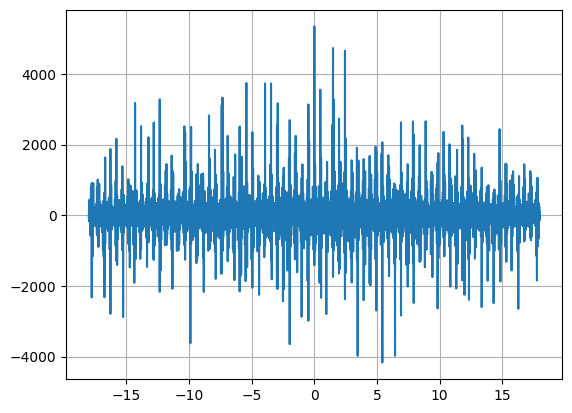

In [21]:
#c = scipy.signal.correlate(rx_samples_compensated, tx_samples_resampled, mode='same')
#cor_lags = scipy.signal.correlation_lags(len(rx_samples_compensated), len(tx_samples_resampled), mode='same') / sample_rate
c = scipy.signal.correlate(rx_samples, tx_samples_resampled_compensated, mode='same')
cor_lags = scipy.signal.correlation_lags(len(rx_samples), len(tx_samples_resampled_compensated), mode='same') / sample_rate
print(c[len(c)//2])

pl.close("c_rx_tx_resampled_compensated")
pl.figure("c_rx_tx_resampled_compensated", clear=True)
pl.plot(cor_lags, c)
# Since tx_samples_resampled have been resampled, we expect the correlation peak at 0
#pl.gca().set_xlim(-0.01, 0.01)
#pl.gca().axvline(1.0, color="black", linestyle=":")
#pl.gca().axvline(1.0 + lt_rx_start, color="black", linestyle="--")
#pl.gca().axvline(1.0 + lt_tx_start, color="black", linestyle=":")
pl.grid()
pl.show()

In [22]:
# Frequency shift the *TX* signal
lt_tx_start, dlt_tx_start = moonPointLightTimeAndDeltaLightTime_spice_FWD(tx_start_time, p_moon)
lt_tx_end, dlt_tx_end = moonPointLightTimeAndDeltaLightTime_spice_FWD(tx_end_time, p_moon)

doppler_start = -dlt_tx_start * frequency
doppler_end = -dlt_tx_end * frequency

# Frequency shift the tx_samples using a simple 'bulk' doppler correction model, linear
# from start to end. Generally good enough for a "look" of a few minutes.
# This means shifting the frequency by the doppler_start frequency plus the
# integral of the change in the doppler factor (doppler_rate) over the rx
# time interval.
doppler_rate = (doppler_end - doppler_start) / (tx_duration * au.s)

t_s = np.arange(len(tx_samples)) / sample_rate
phi_Hz = doppler_start + doppler_rate * t_s / 2
#tx_samples_shifted = tx_samples * np.exp(-1j * 2 * np.pi * (phi_Hz * t_s).value).T
tx_samples_shifted = tx_samples * np.exp(1j * 2 * np.pi * (phi_Hz * t_s).value).T  # NOTE: NEGATIVE SHIFT 

#c = scipy.signal.correlate(rx_samples, tx_samples_shifted, mode='valid')
#print(c[len(c)//2])

#pl.figure("c_rx_tx_shifted", clear=True)
#cor_lags = scipy.signal.correlation_lags(len(rx_samples), len(tx_samples_shifted), mode='valid') / sample_rate
#pl.plot(cor_lags, c)
## Since tx_samples_shifted actually starts at TX_START, we expect the correlation peak at TX_START + lt_rx_start.
#pl.gca().set_xlim(1 + lt_rx_start - 0.01, 1 + lt_rx_start + 0.01)
#pl.gca().axvline(1.0 + lt_rx_start, color="black", linestyle="--")
##pl.gca().axvline(1.0, color="black", linestyle=":")
##pl.gca().axvline(1.0 + lt_tx_start, color="black", linestyle=":")
#pl.grid()
#pl.show()

In [23]:
# HYPOTHESES for why rx and tx compensation aren't symmetrical:
# 1. My FWD SPICE function is (more) busted than the REV function. 

# HYPOTHESES FOR WHY THE ABSOLUTE CORRELATION PEAK DOESN'T OCCUR AT THE PREDICTED TIME
# 1. The SPICE functions are busted.
# 2. The Dwingeloo and/or Stockert clocks are busted.
# 3. Numerical issues plus noise are wreaking havok with the correlation.
# 4. PHASE ??? POLARITY ???

In [24]:
#shift = 1045 # -1140.895
#tx0_sample_times = np.linspace(0, tx_duration, len(tx_samples), endpoint=False)
#tx_samples_shifted = tx_samples * np.exp(1j * 2 * np.pi * shift * tx0_sample_times).T
#c = scipy.signal.correlate(tx_samples_shifted, rx_samples, mode='same')
#print(c[len(c)//2])

In [25]:
# Plots for time resampling method experiments
if 0:  # Check that the tx_shifted waveform fits in the expected time window.
    %matplotlib widget
    pl.figure("rx_tx_shifted_samples", clear=True)
    i_end = -1 # 1000000 # int(sample_rate.value * 5)
    i_skip = 100
    pl.plot(rx_sample_times0[:i_end:i_skip], rx_samples[:i_end:i_skip], '.')
    pl.plot(rx_sample_times0[:i_end:i_skip], tx_samples_resampled[:i_end:i_skip], '.')
    pl.plot(rx_sample_times0[:i_end:i_skip], tx_samples_resampled_compensated[:i_end:i_skip], '.')
    pl.gca().axvline(1.0, color="black", linestyle=":")
    pl.gca().axvline(1.0 + lt_tx_start, color="black", linestyle=":")
    pl.gca().axvline(1.0 + tx_duration + lt_tx_end, color="black", linestyle=":")
    pl.gca().axvline(1.0 + tx_duration + lt_tx_start, color="black", linestyle="--")
    pl.gca().set_xlim(1.0 + tx_duration + lt_tx_end, 1.0 + tx_duration + lt_tx_start)  
    pl.show()

if 0:
    %matplotlib widget
#    cor_lags = scipy.signal.correlation_lags(len(tx_samples_shifted), len(rx_samples), mode='same') / sample_rate
    pl.figure("rx_tx_correlate", clear=True)
    pl.plot(cor_lags, c)
    # If tx_samples and rx_samples{_compensated} both start at 0 time, we expect the correlation at 1 + lt_tx_start
    pl.gca().axvline(1.0, color="black", linestyle=":")
    pl.gca().axvline(1.0 + lt_tx_start, color="black", linestyle=":")
    # If tx_samples_shifted and rx_samples are on the same timebase, we expect the correlation at 0.
    #pl.gca().set_xlim(-1, 1)  
    pl.grid()
    pl.show()

In [26]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)